Generating 1000 simulations...
  Simulation 50...
  Simulation 100...
  Simulation 150...
  Simulation 200...
  Simulation 250...
  Simulation 300...
  Simulation 350...
  Simulation 400...
  Simulation 450...
  Simulation 500...
  Simulation 550...
  Simulation 600...
  Simulation 650...
  Simulation 700...
  Simulation 750...
  Simulation 800...
  Simulation 850...
  Simulation 900...
  Simulation 950...
  Simulation 1000...

Starting model training...
Epoch [10/300], Val Loss: 1.987017
Epoch [20/300], Val Loss: 1.597862
Epoch [30/300], Val Loss: 1.105418
Epoch [40/300], Val Loss: 0.592561
Epoch [50/300], Val Loss: 0.262036
Epoch [60/300], Val Loss: 0.119836
Epoch [70/300], Val Loss: 0.088872
Epoch [80/300], Val Loss: 0.072769
Epoch [90/300], Val Loss: 0.067255
Epoch [100/300], Val Loss: 0.069255
Epoch [110/300], Val Loss: 0.070649
Epoch [120/300], Val Loss: 0.070813
Early stopping at epoch 120


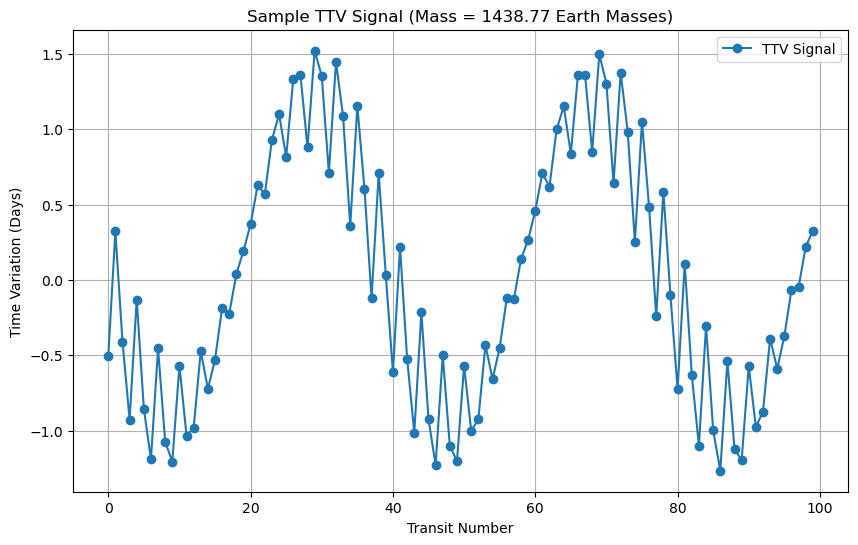

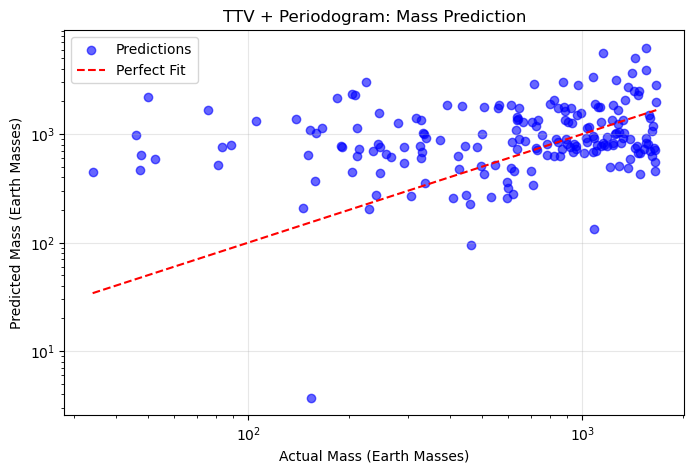


Amplitude-to-Mass Correlation: 0.1587


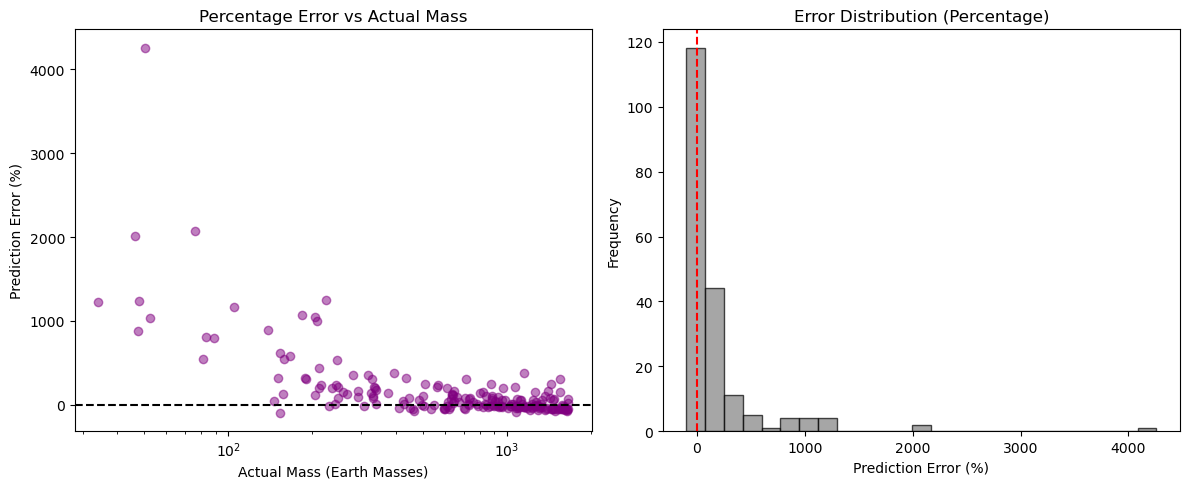

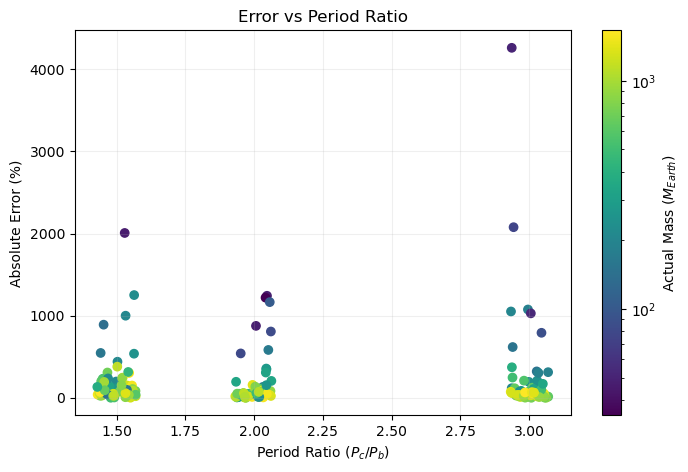


--- Statistical Error Analysis ---
Mean Absolute Error: 0.3574 dex
Root Mean Squared Error: 0.4772 dex
Typical Error: Factor of 2.28x in mass


In [18]:
import numpy as np
import rebound
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from astropy.timeseries import LombScargle
from scipy.stats import pearsonr

#-----------------------------------------------------------------------------
# Script Variables & Physics Constants
#-----------------------------------------------------------------------------
NUM_SIMULATIONS = 1000
MAX_TRANSITS = 100
USE_RESONANCES = True

SOLAR_TO_EARTH = 332946.0
# Assuming 2*pi in simulation = 365.25 days
SIM_TIME_TO_DAYS = 365.25 / (2 * np.pi) 

#-----------------------------------------------------------------------------
# Utility Functions
#-----------------------------------------------------------------------------

def detect_transits(sim, integration_time, dt, max_transits, planet_index):
    """
    Detects the times when a specified planet transits the star (crosses the y-axis
    while in front of the star) within a REBOUND simulation.
    
    Inputs:
        :param sim: the simulation being run
        :param integration_time: the 'time' the sim is to run for
        :param dt: the integration time step
        :param max_transits: max number of transits we want to detect
        :param planet_index: index of the planet we want to detect transits of
    Outputs:
        array of transit times
    """
    transit_times = []
    star = sim.particles[0]             # star is always the first element in our sim (or should be!)
    planet = sim.particles[planet_index]# specify the index of the planet in our sim whose transits we want to detect
    prev_y = planet.y - star.y
    
    time = 0
    while time < integration_time and len(transit_times) < max_transits:
        sim.integrate(sim.t + dt)           # progress simulation
        time = sim.t                        # get time from sim
        curr_y = planet.y - star.y          
        # if the product of previous and current y is negative, they they are on 
        # opposite sides of the y axis, and so there has been a transit of the y-axis
        # if (planet.x - star.x) > 0, then the planet is in front of the star: transit occured
        if prev_y * curr_y < 0 and (planet.x - star.x) > 0:
            # perform linear interpolation to find more precise moment of crossing
            weight = -prev_y / (curr_y - prev_y)
            precise_time = (time - dt) + (weight * dt)
            transit_times.append(precise_time)
        prev_y = curr_y
    return np.array(transit_times)

def detrend_ttv(ttv_data):
    """
    Remove the linear trend from a single TTV array
    
    Inputs:
        array: ttv data
    Outputs:
        array: detrended ttv data
    """
    N = len(ttv_data)                                   # get length of input
    transit_numbers = np.arange(N)                      # create array of transit numbers
    P = np.polyfit(transit_numbers, ttv_data, 1)        # fit straight line to ttv data
    return ttv_data - (P[0] * transit_numbers + P[1])   # subtract line from ttv and return

#-----------------------------------------------------------------------------
# PHASE 1: GENERATE DATA WITH PERIODOGRAM
#-----------------------------------------------------------------------------

def generate_simulation_data(num_simulations, max_transits):
    """
    Generate the simulation data to train our model
    Inputs:
        :param num_simulations: number of simulations to be run
        :param max_transits: number of transits to reach before terminating a sim
    Outputs:
        array of physical features
        array of masses
        array of TTVs
    """
    print(f"Generating {num_simulations} simulations...")
    all_features = []
    all_masses = []
    all_ttvs = []
    
    # Use strong resonances to ensure a learnable signal
    resonances = [1.5, 2.0, 3.0] 
    # as an example, a resonance ration of 1.5, or 3/2, would mean planet B's period is 
    # 1.5 times planet C's, or put another way, by the time planet B has orbited three times,
    # planet C has orbited only twice
    
    for i in range(num_simulations):
        if (i + 1) % 50 == 0: print(f"  Simulation {i+1}...")
        
        try:
            # Randomize Planet B
            m_b = np.random.uniform(1e-6, 1e-4) # mass (earth range to jupiter range)
            P_b = np.random.uniform(2*np.pi, 4*np.pi)   # period
            e_b = np.random.uniform(0.0, 0.02)  # eccentricity
            
            # Randomize Planet C (The Perturber)
            # define if setting period ratio from resonance array or set range
            if USE_RESONANCES:
                ratio = np.random.choice(resonances) + np.random.uniform(-0.07, 0.07) # ratio of period to planet B
            else:
                ratio = np.random.uniform(1.25, 2.5)#
            m_c = np.random.uniform(1e-4, 5e-3) # mass
            P_c = P_b * ratio                   # period
            e_c = np.random.uniform(0.0, 0.05)  # eccentricity

            dt = P_b / 50   # time step to be used by integrators

            # Unperturbed Simulation
            sim_u = rebound.Simulation()    # create simulation                             
            sim_u.integrator = "whfast";    # specify the integrator                        
            sim_u.dt = dt                   # set time step of integrator                   
            sim_u.add(m=1.0);               # add 1 solar mass star to sim                  
            sim_u.add(m=m_b, P=P_b, e=e_b)  # add planet B to sim                           
            sim_u.move_to_com()             # set centre of mass of system as the origin
            transits_u = detect_transits(   # in unperturbed sim, find transits of planet B
                sim_u,                  # simulation to use
                P_b*(max_transits+5),   # integration time 
                dt,                     # integrator time step 
                max_transits,           # max number of transits we're looking for  
                1                       # index of transiting planet in simulation  
            )   

            # Perturbed Simulation  
            sim_p = rebound.Simulation()    # create simulation                            
            sim_p.integrator = "whfast";    # specify the integrator                       
            sim_p.dt = dt                   # set time step of integrator                  
            sim_p.add(m=1.0);               # add 1 solar mass star to sim                 
            sim_p.add(m=m_b, P=P_b, e=e_b)  # add planet B to sim                          
            sim_p.add(m=m_c, P=P_c, e=e_c)  # in unperturbed sim, find transits of planet B
            sim_p.move_to_com()             # set centre of mass of system as the origin
            transits_p = detect_transits(
                sim_p,                  # simulation to use
                P_b*(max_transits+5),   # integration time
                dt,                     # integrator time step
                max_transits,           # max number of transits we're looking for  
                1                       # index of transiting planet in simulation
            )

            # proceed if we have a sufficient number of transits in both simulations
            if len(transits_u) >= max_transits and len(transits_p) >= max_transits:
                ttv_vec = detrend_ttv(transits_p[:max_transits] - transits_u[:max_transits])
                
                # Convert TTV wiggles into a frequency spectrum to identify the dominant
                # orbital resonance frequency between the planets.
                # Search for cycles between 3 transits and 50 transits, with 40 sample bins
                freqs = np.linspace(1/50, 1/3, 40)
                power = LombScargle(np.arange(max_transits), ttv_vec).power(freqs)
                
                # Feature Construction: [Amplitude, Power Spectrum, Phys Params]
                amp = np.std(ttv_vec)
                phys = [m_b, P_b, ratio, e_b]    # our physical features of the planets
                
                features = np.hstack(([amp], power, phys)) # stack our features
                all_features.append(features)
                all_masses.append(m_c)
                all_ttvs.append(ttv_vec)


        except Exception: 
            print(f"Exception in simulation {i}. Proceeding to next simulation.")
            continue

    return np.array(all_features), np.array(all_masses), np.array(all_ttvs)

#-----------------------------------------------------------------------------
# PHASE 2: MASS PREDICTOR MODEL
#-----------------------------------------------------------------------------

class MassPredictor(nn.Module):
    """
    Neural Network model designed to estimate planetary mass from 
    TTV amplitudes and periodogram features.
    Because we're working with normalised data and will have negative values,
    use LeakyReLU to stop neurons "dying".
    """
    def __init__(self, input_size):
        super(MassPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 45), 
            nn.BatchNorm1d(45),        # Stabilizes training by normalizing layer outputs
            nn.LeakyReLU(0.1),          # Allows small gradients for negative values to prevent "dead neurons"
            nn.Dropout(0.1),            # Randomly zeros 10% of neurons to prevent overfitting to specific noise
            
            nn.Linear(45, 22),
            nn.BatchNorm1d(22),
            nn.LeakyReLU(0.1),

            #nn.Linear(128, 64),
            #nn.BatchNorm1d(64),
            #nn.LeakyReLU(0.1),
            
            nn.Linear(22, 1)
        )

    def forward(self, x):
        return self.network(x)

def train_model(model, X_train, y_train, X_val, y_val, epochs=200, batch_size=16):           
    print("\nStarting model training...")
    # --- Data Preparation ---
    # Convert NumPy arrays to PyTorch Tensors (the required data format for the model)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    # .view(-1, 1) ensures the target labels have the correct shape for the loss function
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    # HuberLoss is robust to outliers, combining Mean Squared Error and Mean Absolute Error
    criterion = nn.HuberLoss()                                                                            
    # Adam optimizer handles weight updates; weight_decay adds L2 regularization to prevent overfitting
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3) 
    # Scheduler reduces the learning rate when the validation loss plateaus to fine-tune results
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

    # --- Early Stopping Setup ---
    best_val_loss, patience_counter, max_patience = float('inf'), 0, 30
    best_model_state = None

    for epoch in range(epochs):
        # 1. Training Phase
        model.train() # Set model to training mode (enables Dropout/BatchNorm)
        train_loss = 0
        indices = torch.randperm(len(X_train_t)) # Shuffle data every epoch to improve generalization. Prevents learning order.
        
        # Mini-batch loop
        for i in range(0, len(X_train_t), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_X, batch_y = X_train_t[batch_indices], y_train_t[batch_indices]
            # Forward pass: Compute predicted outputs by passing inputs to the model
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            # Backward pass and optimization
            optimizer.zero_grad()   # Clear previous gradients
            loss.backward()         # Compute gradients using backpropagation
            optimizer.step()        # Update model weights
            train_loss += loss.item()
        
        # 2. Validation Phase
        model.eval() # Set model to evaluation mode (disables Dropout/BatchNorm)
        with torch.no_grad():   # Disable gradient calculation to save memory and time
            val_loss = criterion(model(X_val_t), y_val_t)
        
        scheduler.step(val_loss) # Update learning rate based on validation performance
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Val Loss: {val_loss.item():.6f}')
        
        # --- Early Stopping Logic ---
        # If model improves, save the current best weights
        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            best_model_state = model.state_dict().copy()
        else:
            # If no improvement, increment counter; stop training if max_patience reached
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Reload the best performing weights before returning the model
    if best_model_state:
        model.load_state_dict(best_model_state)
    return model

#-----------------------------------------------------------------------------
# PHASE 3: TRAINING AND EVALUATION
#-----------------------------------------------------------------------------

if __name__ == "__main__":
    X_raw, y_raw, ttvs = generate_simulation_data(NUM_SIMULATIONS, MAX_TRANSITS)
    
    # Log Scaling for Mass (converts tiny decimals to manageable numbers like -1 to -4)
    y_log = np.log10(y_raw)
    
    # Preprocessing
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    
    # Data Splitting: Train (64%), Validation (16%), Test (20%)
    X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    
    # Initialize and Train
    model = MassPredictor(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_val, y_val, epochs=300)

    # Results
    model.eval()
    with torch.no_grad():
        test_preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
    
    # Plotting
    # Visualize sample TTV signal
    plt.figure(figsize=(10, 6))
    plt.plot(ttvs[0] * SIM_TIME_TO_DAYS, 'o-', label='TTV Signal')
    plt.title(f'Sample TTV Signal (Mass = {y_raw[0]*SOLAR_TO_EARTH:.2f} Earth Masses)')
    plt.xlabel('Transit Number')
    plt.ylabel('Time Variation (Days)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # predicted mass vs actual
    plt.figure(figsize=(8, 5))
    # Convert logs back to linear Earth masses
    y_test_earth = 10**y_test * SOLAR_TO_EARTH
    preds_earth = 10**test_preds * SOLAR_TO_EARTH
    plt.scatter(y_test_earth, preds_earth, alpha=0.6, color='blue', label='Predictions')
    plt.plot([y_test_earth.min(), y_test_earth.max()], [y_test_earth.min(), y_test_earth.max()], 'r--', label='Perfect Fit')
    plt.xscale('log') # Use log scales to see the full range clearly
    plt.yscale('log')
    plt.xlabel("Actual Mass (Earth Masses)")
    plt.ylabel("Predicted Mass (Earth Masses)")
    plt.title("TTV + Periodogram: Mass Prediction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    corr, _ = pearsonr(X_raw[:, 0], y_raw)
    print(f"\nAmplitude-to-Mass Correlation: {corr:.4f}")



    # --- ERROR ANALYSIS ---

    # Plot 1: Percentage Residuals vs Actual Mass
    # This calculates how many percent the prediction was away from the true value
    # A value of 20 means "Predicted 20% more than truth", -10 means "10% less than truth"
    residuals_percentage = (10**(test_preds - y_test) - 1) * 100
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_earth, residuals_percentage, alpha=0.5, color='purple')
    plt.axhline(0, color='black', linestyle='--')
    plt.xscale('log') # Keep x-axis as log Earth masses for clarity
    plt.xlabel("Actual Mass (Earth Masses)")
    plt.ylabel("Prediction Error (%)")
    plt.title("Percentage Error vs Actual Mass")

    # Plot 2: Error Distribution Histogram (%)
    # This plot assesses model bias and variance. A "perfect" model would result in 
    # a narrow spike centered exactly at the red line (0%). A distribution shifted 
    # to the right indicates consistent overestimation, while a wide distribution 
    # indicates high variance (low precision) in the mass predictions.
    plt.subplot(1, 2, 2)
    plt.hist(residuals_percentage, bins=25, color='gray', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel("Prediction Error (%)")
    plt.ylabel("Frequency")
    plt.title("Error Distribution (Percentage)")
    plt.tight_layout()
    plt.show()


    # --- Plot: Error vs. Period Ratio ---
    # This plot tests the fundamental TTV theory: predictions should be most accurate 
    # (lowest absolute error) when the period ratio is near a strong mean-motion resonance 
    # (e.g., 1.5 for 3:2, or 2.0 for 2:1). The color scale shows that high-mass systems 
    # (where TTV signal is strongest) are distributed across the error landscape.
    
    # Re-establishing the link between the separated test labels (y_test) and the original 
    # physical parameters (X_raw, specifically the Period Ratio at index -2).
    test_indices = []
    for val in y_test:
        idx = np.where(y_log == val)[0][0]
        test_indices.append(idx)

    # Extract the period ratio (Pc/Pb) for all data points in the test set.
    test_ratios = X_raw[test_indices, -2] 

    plt.figure(figsize=(8, 5))
    # Use log normalization (mcolors.LogNorm) on the colorbar to clearly show mass 
    # differences across orders of magnitude (Earth to Jupiter mass).
    plt.scatter(test_ratios, np.abs(residuals_percentage), c=y_test_earth, cmap='viridis', norm=mcolors.LogNorm())
    plt.colorbar(label='Actual Mass ($M_{Earth}$)')
    plt.xlabel("Period Ratio ($P_c / P_b$)")
    plt.ylabel("Absolute Error (%)")
    plt.title("Error vs Period Ratio")
    plt.grid(True, alpha=0.2)
    plt.show()


    # --- Statistical Performance Summary ---

    # Mean Absolute Error (MAE) represents the average distance between the predicted 
    # and actual mass in Log10 space (dex). It provides a stable measure of typical error.
    mae = mean_absolute_error(y_test, test_preds)

    # Root Mean Squared Error (RMSE) penalizes larger errors more heavily than MAE. 
    # A significant gap between RMSE and MAE would suggest the presence of extreme outliers 
    # where the model's predictions were significantly off.
    rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    print(f"\n--- Statistical Error Analysis ---")
    print(f"Mean Absolute Error: {mae:.4f} dex") 
    print(f"Root Mean Squared Error: {rmse:.4f} dex")

    # Physical Interpretation:
    # Because we trained on Log10 masses, a "dex" error is logarithmic. 
    # By calculating 10^MAE, we convert the average log-error into a linear scale factor.
    # For example: an MAE of 0.3 dex indicates a factor of 2.0x error (10^0.3), 
    # meaning the predicted mass is typically within half or double the true mass.
    print(f"Typical Error: Factor of {10**mae:.2f}x in mass")